In [2]:
# Load the trained Wrc
import torch
import numpy as np
from matplotlib import pyplot as plt
model_dict = torch.load(f'../time_exp/2TS_1_rnn.pth', map_location=torch.device('cuda'))

# Get the weights and biases
Wrc = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()

# Load Wrc_theory
Wrc_theory = np.load('Wrc_theory.npy')

# Load Wrc_space
model_dict = torch.load(f'../space_exp/square_room_rnn.pth', map_location=torch.device('cuda'))
Wrc_space = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()

### Sort Wrc and plug it back to the RNN

The observation is, after sorting (put most of positive entries to upper right), the time cell doesn't show up.

In [3]:
# Calculate the ratio of positive entries to total entries
import numpy as np
num_positive = np.sum(Wrc > 0)
num_negative = np.sum(Wrc < 0)
total_entries = 512 * 512
ratio_positive = num_positive / total_entries
ratio_negative = num_negative / total_entries
print(f'Ratio of positive entries to total entries: {ratio_positive:.4f}')
print(f'Ratio of negative entries to total entries: {ratio_negative:.4f}')

Ratio of positive entries to total entries: 0.3613
Ratio of negative entries to total entries: 0.6387


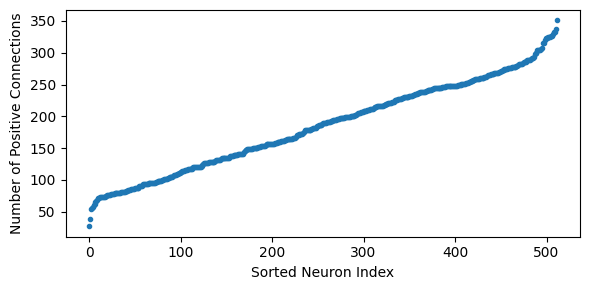

In [47]:
# Get the number of positive entries in each row
positive_counts_per_row = np.sum(Wrc > 0, axis=1)
sorted_counts = np.sort(positive_counts_per_row)
# Plot positive counts vs neuron index
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(sorted_counts, marker='o', linestyle='None', markersize=3)
plt.xlabel('Sorted Neuron Index')
plt.ylabel('Number of Positive Connections')    
plt.tight_layout()
plt.show()

In [3]:
# Extract the diagonal elements
diags = np.diag(Wrc)
# Check if all diags are negative
num_neg = np.sum(diags < 0)
print(f'Number of negative diagonal elements: {num_neg} out of {len(diags)}')

Number of negative diagonal elements: 441 out of 512


### Compare spectrum between Wrc and Wtheory

In [31]:
def spectral_similarity(A, B, k=None):
    eigA = np.linalg.eigvals(A)
    eigB = np.linalg.eigvals(B)
    # sort by real part for comparison
    eigA = np.sort_complex(eigA)
    eigB = np.sort_complex(eigB)
    dist = np.linalg.norm(np.sort(eigA) - np.sort(eigB)) / np.linalg.norm(eigA)
    return {'Eigen_distance': dist}

W_thory = np.load('Wrc_theory.npy')
spec_sim = spectral_similarity(Wrc, W_thory)
print(spec_sim)

{'Eigen_distance': np.float64(4.601980983856341)}


In [32]:
def baseline_eigen_distance(A, n_samples=100):
    eigA = np.linalg.eigvals(A)
    norms = []
    for _ in range(n_samples):
        B = np.random.permutation(A.flatten()).reshape(A.shape)
        eigB = np.linalg.eigvals(B)
        dist = np.linalg.norm(np.sort_complex(eigA) - np.sort_complex(eigB)) / np.linalg.norm(eigA)
        norms.append(dist)
    return np.mean(norms), np.std(norms)
mean_dist, std_dist = baseline_eigen_distance(Wrc, n_samples=100)
print(f'Baseline eigen distance: mean={mean_dist:.4f}, std={std_dist:.4f}')

Baseline eigen distance: mean=1.1003, std=0.0151


### Figure out Wrc structure

Firstly, it's not symmetric. Make Wrc symmetric doesn't give time cells.

In [3]:
asymmetry_ratio = np.linalg.norm(Wrc - Wrc.T, 'fro') / (np.linalg.norm(Wrc, 'fro'))
print("Asymmetry ratio =", asymmetry_ratio)

Asymmetry ratio = 1.5608238


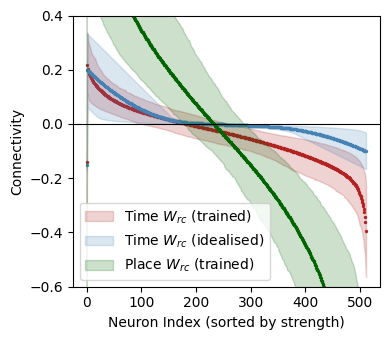

In [9]:
def sortW(W):
    # Iterate over rows of Wrc
    Wrc_sorted = np.zeros_like(W)
    for irow, row in enumerate(W):
        # Except itself, sort the indices of the other neurons by weight
        row_values = np.zeros_like(row)
        row_values[0] = row[irow]  # keep self-connection
        # Get the indices of other neurons sorted by weight
        other_indices = np.argsort(row)
        sorted_indices = [i for i in other_indices if i != irow]
        sorted_indices = sorted_indices[::-1]  # descending order
        # Fill in the row_values with sorted weights
        for j, idx in enumerate(sorted_indices):
            row_values[j + 1] = row[idx]
        Wrc_sorted[irow] = row_values
        
    mean_sorted = np.mean(Wrc_sorted, axis=0)
    percentile_16 = np.percentile(Wrc_sorted, 16, axis=0)
    percentile_84 = np.percentile(Wrc_sorted, 84, axis=0)
    return mean_sorted, percentile_16, percentile_84

mean_sorted, percentile_16, percentile_84 = sortW(Wrc)
mean_theory, p16_theory, p84_theory = sortW(Wrc_theory)
mean_space, p16_space, p84_space = sortW(Wrc_space)

# Plot the sorted Wrc
plt.figure(figsize=(4,3.5))
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.fill_between(range(len(mean_sorted)), percentile_16, percentile_84, alpha=0.2,
                 color='firebrick', label=r'Time $W_{rc}$ (trained)')
plt.scatter(range(len(mean_sorted)), mean_sorted, color='firebrick', s=2)
plt.fill_between(range(len(mean_theory)), p16_theory, p84_theory, alpha=0.2,
                 color='steelblue', label=r'Time $W_{rc}$ (idealised)')
plt.scatter(range(len(mean_theory)), mean_theory, color='steelblue', s=2)
plt.fill_between(range(len(mean_space)), p16_space, p84_space, alpha=0.2,
                 color='darkgreen', label=r'Place $W_{rc}$ (trained)')
plt.scatter(range(len(mean_space)), mean_space, color='darkgreen', s=2)
# plt.title('Wrc with Sorted Rows')
plt.legend(loc='lower left')
plt.xlabel('Neuron Index (sorted by strength)')
plt.ylabel('Connectivity')
# plt.yscale('symlog')
plt.ylim(-0.6, 0.4)
plt.tight_layout()
plt.savefig('Connection_vs_distance.png', transparent=True, dpi=500)

This means neuron strongly inhibits itself and exhibits weakly global inhibition. 

In [ ]:
def check_locality(W):
    n = W.shape[0]
    dist = np.abs(np.arange(n)[:,None] - np.arange(n)[None,:]) # (512, 512)
    dist = np.minimum(dist, n - dist)  # circular distance

    # Get the mean
    mean_weight_by_dist = [np.mean(W[dist == d]) for d in range(n//2)]
    # Get the 16th and 84th percentiles
    percentile_16 = [np.percentile(W[dist == d], 16) for d in range(n//2)]
    percentile_84 = [np.percentile(W[dist == d], 100) for d in range(n//2)]
    percentile_50 = [np.percentile(W[dist == d], 50) for d in range(n//2)]
    # Plot mean with shaded percentiles
    plt.figure(figsize=(5,4))
    plt.fill_between(range(n//2), percentile_16, percentile_84, alpha=0.3,
                     color='steelblue',label='16th-84th percentile')
    plt.plot(percentile_50, color='steelblue', linestyle='--', label='Median')
    plt.plot(mean_weight_by_dist, color='firebrick', label='Mean')
    # plt.title("Mean connection vs distance (circular)")
    plt.xlabel("Distance (index difference)")
    plt.ylabel("Weight")
    plt.legend()
    plt.tight_layout()  
    
check_locality(Wrc)
plt.savefig('Connection_vs_distance.png', transparent=True, dpi=500)

In [ ]:
S = 0.5*(Wrc + Wrc.T)
K = 0.5*(Wrc - Wrc.T)
direction_ratio = np.linalg.norm(K, 'fro') / (np.linalg.norm(Wrc, 'fro'))
symmetric_ratio = np.linalg.norm(S, 'fro') / (np.linalg.norm(Wrc, 'fro'))
print("Symmetric ratio:", symmetric_ratio**2)
print("Directionality ratio:", direction_ratio**2, 1-symmetric_ratio**2)

mean_upper= -0.02029507  mean_lower= -0.01977573
max Re(λ) = 5.3360896
spectral radius = 28.139124


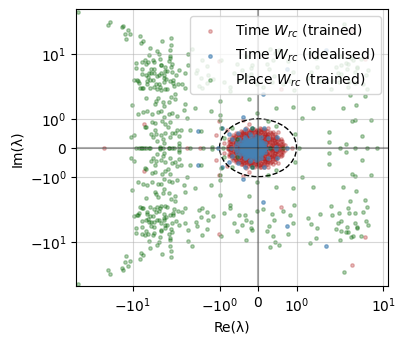

In [11]:
eig = np.linalg.eigvals(Wrc)
eig_space = np.linalg.eigvals(Wrc_space)
eig_theory = np.linalg.eigvals(Wrc_theory)
plt.figure(figsize=(4,3.5))
plt.scatter(eig.real, eig.imag, s=6, c='firebrick', alpha=0.3, label=r'Time $W_{rc}$ (trained)')
# Plot a circle of radius 1
circle = plt.Circle((0, 0), 1.0, color='black', alpha=1, linestyle='--', fill=False)
plt.gca().add_artist(circle)
plt.scatter(eig_theory.real, eig_theory.imag, s=6, c='steelblue', alpha=0.6, label=r'Time $W_{rc}$ (idealised)')
plt.scatter(eig_space.real, eig_space.imag, s=6, c='darkgreen', alpha=0.3, label=r'Place $W_{rc}$ (trained)')
plt.axhline(0,c='k', alpha=0.3); plt.axvline(0,c='k', alpha=0.3)
plt.xlabel('Re(λ)'); plt.ylabel('Im(λ)')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.xscale('symlog')
plt.yscale('symlog')
plt.savefig('eigen_spectrum.png', transparent=True, dpi=500)
# plt.title('Eigen spectrum')
upper = np.triu(Wrc, 1); lower = np.tril(Wrc, -1)
print('mean_upper=', np.nanmean(upper), ' mean_lower=', np.nanmean(lower))
print("max Re(λ) =", np.max(eig.real))
print("spectral radius =", np.max(np.abs(eig)))

### PCA

Simulate how a higher dimensional representation vector $x\in\mathbb{R}^{512}$ changes with time under the matrix $W_{rc}$. Given the dynamics:

\begin{equation}\dot{x}=W_{rc}x\end{equation}

Because the trajectory in 2D space is spiral and decaying, the excitation between neurons propagates and returns to itself, e.g., A --> B --> C --> D --> A. The connectivity in this direction is positive. We call this a "local loop".

The decay means the circumference of the local loop is decreasing. 

/home/shannon/miniconda3/envs/STCell/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:773: RuntimeWarning: overflow encountered in square
  self.explained_variance_ = (S**2) / (n_samples - 1)
/home/shannon/miniconda3/envs/STCell/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:784: RuntimeWarning: overflow encountered in square
  X_centered **= 2
/home/shannon/miniconda3/envs/STCell/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:787: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
/home/shannon/miniconda3/envs/STCell/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:791: RuntimeWarning: invalid value encountered in scalar subtract
  self.noise_variance_ = total_var - xp.sum(self.explained_variance_)


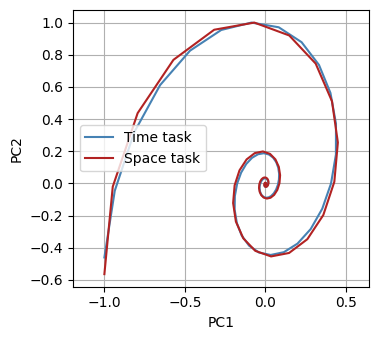

In [ ]:
def simulate_linear(W, x0=None, dt=0.01, T=10):
    N = W.shape[0]
    if x0 is None:
        x0 = np.random.randn(N)
    t = np.arange(0, T, dt)
    X = np.zeros((len(t), N))
    X[0] = x0
    for i in range(1, len(t)):
        X[i] = X[i-1] + dt * (W @ X[i-1])
    return t, X

# simulate and project to top 2 PCA
from sklearn.decomposition import PCA

# np.random.seed(50)

x0 = np.random.randn(Wrc.shape[0])
t, X = simulate_linear(Wrc, x0=x0,T=10)
t, X_space = simulate_linear(Wrc_space, x0=x0, T=10)
t, X_theory = simulate_linear(Wrc_theory, x0=x0, T=10)

pca = PCA(n_components=2)
proj = pca.fit_transform(X)
pca = PCA(n_components=2)
proj_space = pca.fit_transform(X_space)
pca = PCA(n_components=2)
proj_theory = pca.fit_transform(X_theory)

plt.figure(figsize=(4, 3.5))
# Rescale for better visualization
proj[:,0] /= np.max(np.abs(proj[:,0]))
proj[:,1] /= np.max(np.abs(proj[:,1]))
proj_space[:,0] /= np.max(np.abs(proj_space[:,0]))
proj_space[:,1] /= np.max(np.abs(proj_space[:,1]))
proj_theory[:,0] /= np.max(np.abs(proj_theory[:,0]))
proj_theory[:,1] /= np.max(np.abs(proj_theory[:,1]))
plt.plot(proj[:,0], proj[:,1], color='steelblue', label='Time task')
plt.plot(proj_space[:,0], proj_space[:,1], color='firebrick', label='Space task')
# plt.plot(proj_theory[:,0], proj_theory[:,1], color='green', label='Wrc theory')
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.axis('equal')
plt.grid(True)
# plt.savefig('Trajectory_2D_PCA.png', transparent=True, dpi=500)

### Is Wrc normal?

Is $W_{rc}^T W_{rc} = W_{rc} W_{rc}^T$?

In [69]:
# Check if Wrc is a normal matrix
W_WT = Wrc @ Wrc.T
WT_W = Wrc.T @ Wrc
normality_deviation = np.linalg.norm(W_WT - WT_W, 'fro') / np.linalg.norm(Wrc, 'fro')**2
print("Normality deviation =", normality_deviation)

Normality deviation = 0.41895738
